In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
import torch
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel

dtype = torch.float16
device = torch.device("cuda")

vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae", use_safetensors=True)
tokenizer = CLIPTokenizer.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="text_encoder", use_safetensors=True
)
unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet", use_safetensors=True
)

torch_device = torch.device('cuda')
vae.to(torch_device)
text_encoder.to(torch_device)
unet.to(torch_device)

from diffusers import EulerDiscreteScheduler

scheduler = EulerDiscreteScheduler.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="scheduler")

@torch.no_grad
def get_image(latents, nrow, ncol):
    image = vae.decode(latents / vae.config.scaling_factor, return_dict=False)[0]
    image = (image / 2 + 0.5).clamp(0, 1).squeeze()
    image = (image.permute(0, 2, 3, 1) * 255).to(torch.uint8)
    rows = []
    for row_i in range(nrow):
        row = []
        for col_i in range(ncol):
            i = row_i*nrow + col_i
            row.append(image[i])
        rows.append(torch.hstack(row))
    image = torch.vstack(rows)
    return Image.fromarray(image.cpu().numpy())

@torch.no_grad
def get_text_embedding(prompt):
    text_input = tokenizer(
        prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt"
    )
    return text_encoder(text_input.input_ids.to(torch_device))[0]

from torch.nn.attention import SDPBackend, sdpa_kernel

@torch.no_grad
def get_vel(t, sigma, latents, embeddings, eps=None, get_div=False):
    v = lambda _x, _e: unet(_x / ((sigma**2 + 1) ** 0.5), t, encoder_hidden_states=_e).sample
    embeds = torch.cat(embeddings)
    latent_input = latents
    if get_div:
        with sdpa_kernel(SDPBackend.MATH):
            vel, div = torch.func.jvp(v, (latent_input, embeds), (eps, torch.zeros_like(embeds)))
            div = -(eps*div).sum((1,2,3))
    else:
        vel = v(latent_input, embeds)
        div = torch.zeros([len(embeds)], device=torch_device)
    return vel, div

/home/molef/micromamba/envs/jaxgpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2025-09-27 15:35:53.853021: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-27 15:35:53.920758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758980153.950317  355162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758980153.958140  355162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attemp

# Superposition (logical `AND`)

## Deterministic

In [6]:
obj_prompt = ["a sailboat"]
bg_prompt = ["cloudy blue sky"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion
num_inference_steps = 100  # Number of denoising steps
guidance_scale = 7.5  # Scale for classifier-free guidance
generator = torch.cuda.manual_seed(1)  # Seed generator to create the initial latent noise
# batch_size = len(obj_prompt)
batch_size = 1

obj_embeddings = get_text_embedding(obj_prompt * batch_size)
bg_embeddings = get_text_embedding(bg_prompt * batch_size)
uncond_embeddings = get_text_embedding([""] * batch_size)
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
    device=torch_device,
)
latents = latents * scheduler.init_noise_sigma

In [7]:
lift = 0.0

scheduler.set_timesteps(num_inference_steps)
ll_obj = torch.zeros((num_inference_steps+1, batch_size), device=torch_device)
ll_bg = torch.zeros((num_inference_steps+1, batch_size), device=torch_device)
kappa = 0.5*torch.ones((num_inference_steps+1, batch_size), device=torch_device)
for i, t in enumerate(scheduler.timesteps):
  dsigma = scheduler.sigmas[i + 1] - scheduler.sigmas[i]
  sigma = scheduler.sigmas[i]
  eps = torch.randint_like(latents, 2, dtype=latents.dtype)*2-1
  vel_obj, dlog_obj = get_vel(t, sigma, latents, [obj_embeddings], eps, True)
  vel_bg, dlog_bg = get_vel(t, sigma, latents, [bg_embeddings], eps, True)
  vel_uncond, _ = get_vel(t, sigma, latents, [uncond_embeddings], eps, False)
  
  kappa[i+1] = sigma*(dlog_obj - dlog_bg)+((vel_obj-vel_bg)*(vel_obj+vel_bg)).sum((1,2,3)) + lift/dsigma*sigma/num_inference_steps
  kappa[i+1] += -((vel_obj-vel_bg)*(vel_uncond + guidance_scale*(vel_bg-vel_uncond))).sum((1,2,3))
  kappa[i+1] /= guidance_scale*((vel_obj-vel_bg)**2).sum((1,2,3))

  vf = vel_uncond + guidance_scale*((vel_bg - vel_uncond) + kappa[i+1][:,None,None,None]*(vel_obj-vel_bg))
  latents += dsigma*vf
  ll_obj[i+1] = ll_obj[i] + dsigma*(dlog_obj - ((-vel_obj/sigma)*(vel_obj-vf)).sum((1,2,3)))
  ll_bg[i+1] = ll_bg[i] + dsigma*(dlog_bg - ((-vel_bg/sigma)*(vel_bg-vf)).sum((1,2,3)))

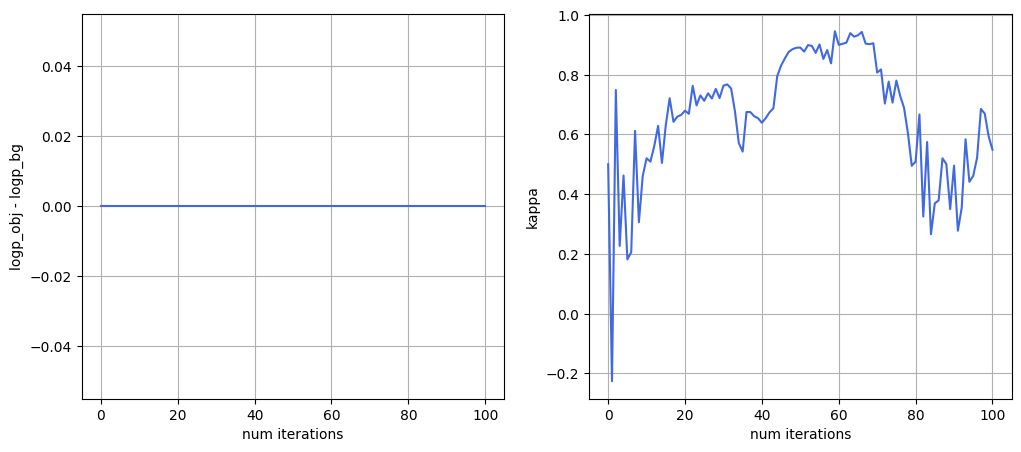

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot((ll_obj-ll_bg).cpu().numpy(), c='royalblue')
plt.ylabel('logp_obj - logp_bg')
plt.xlabel('num iterations')
plt.grid()
plt.subplot(122)
plt.plot(kappa.cpu().numpy(), c='royalblue')
plt.ylabel('kappa')
plt.xlabel('num iterations')
plt.grid()

## Stochastic

In [8]:
# JAX VERSION
# @jax.jit
# def get_stoch_dll(t,dt,x,dx,sscore):
#   output = ndim*dt*dlog_alphadt(t) - dt*beta(t)*(sscore**2)/jnp.exp(log_sigma(t))
#   output += ((dx + dt*dlog_alphadt(t)*x)*sscore/jnp.exp(log_sigma(t)))
#   return output.sum(1)

# @jax.jit
# def select_kappa(ikey,t,dt,x,sdlogdx_1,sdlogdx_2):
#   noise = jnp.sqrt(2*jnp.exp(log_sigma(t))*beta(t)*dt)*random.normal(ikey, shape=(bs,2))
#   dx_ind = -dt*(dlog_alphadt(t)*x - 2*beta(t)*sdlogdx_2) + noise
#   kappa = -dt*beta(t)*(sdlogdx_1-sdlogdx_2)*(sdlogdx_1+sdlogdx_2)/jnp.exp(log_sigma(t)) 
#   kappa += ((dx_ind + dt*dlog_alphadt(t)*x)*(sdlogdx_1-sdlogdx_2)/jnp.exp(log_sigma(t)))
#   kappa = -kappa.sum(1)/(dt*2*beta(t)*(sdlogdx_1-sdlogdx_2)**2/jnp.exp(log_sigma(t))).sum(1)
#   return kappa

# TORCH derivation of kappa
# (-torch.abs(dsigma)/sigma*(vel_obj)**2 - (dx*(vel_obj/sigma))).sum((1,2,3)) = (-torch.abs(dsigma)/sigma*(vel_bg)**2 - (dx*(vel_bg/sigma))).sum((1,2,3))
# (torch.abs(dsigma)*(vel_bg-vel_obj)*(vel_bg+vel_obj)/sigma).sum((1,2,3)) = (dx*((vel_obj-vel_bg)/sigma)).sum((1,2,3))
# dx_ind = 2*dsigma*(vel_uncond + guidance_scale*(vel_bg - vel_uncond)) + noise
# dx_dep = 2*dsigma*guidance_scale*(vel_obj-vel_bg)
# kappa = (torch.abs(dsigma)*(vel_bg-vel_obj)*(vel_bg+vel_obj)/sigma).sum((1,2,3))-(dx_ind*((vel_obj-vel_bg)/sigma)).sum((1,2,3))
# kappa /= (dx_dep*((vel_obj-vel_bg)/sigma)).sum((1,2,3))
###############################################
# dx_ind = 2*dsigma*(vel_uncond + guidance_scale*(vel_bg - vel_uncond)) + noise
# kappa = (torch.abs(dsigma)*(vel_bg-vel_obj)/sigma*(vel_bg+vel_obj)).sum((1,2,3))-(dx_ind*((vel_obj-vel_bg)/sigma)).sum((1,2,3))
# kappa /= 2*dsigma*guidance_scale*((vel_obj-vel_bg)**2/sigma).sum((1,2,3))
###############################################
# dx_ind = 2*dsigma*(vel_uncond + guidance_scale*(vel_bg - vel_uncond)) + noise
# kappa = (torch.abs(dsigma)*(vel_bg-vel_obj)*(vel_bg+vel_obj)).sum((1,2,3))-(dx_ind*((vel_obj-vel_bg))).sum((1,2,3))
# kappa /= 2*dsigma*guidance_scale*((vel_obj-vel_bg)**2).sum((1,2,3))

In [9]:
obj_prompt = ["brazilian rainforest"] 
bg_prompt = ["a shape of a teapot"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion
num_inference_steps = 100  # Number of denoising steps MUST BE > 1000
guidance_scale = 7.5  # Scale for classifier-free guidance
generator = torch.cuda.manual_seed(1)  # Seed generator to create the initial latent noise
# batch_size = len(obj_prompt)
batch_size = 6

obj_embeddings = get_text_embedding(obj_prompt * batch_size)
bg_embeddings = get_text_embedding(bg_prompt * batch_size)
uncond_embeddings = get_text_embedding([""] * batch_size)
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
    device=torch_device,
)
scheduler.set_timesteps(num_inference_steps)
latents = latents * scheduler.init_noise_sigma

In [10]:
lift = 0.0
ll_obj = torch.ones((num_inference_steps+1,batch_size), device=torch_device)
ll_bg = torch.ones((num_inference_steps+1,batch_size), device=torch_device)
kappa = 0.5*torch.ones((num_inference_steps+1,batch_size), device=torch_device)
for i, t in enumerate(scheduler.timesteps):
  dsigma = scheduler.sigmas[i + 1] - scheduler.sigmas[i]
  sigma = scheduler.sigmas[i]
  vel_obj, _ = get_vel(t, sigma, latents, [obj_embeddings])
  vel_bg, _ = get_vel(t, sigma, latents, [bg_embeddings])
  vel_uncond, _ = get_vel(t, sigma, latents, [uncond_embeddings])
  
  noise = torch.sqrt(2*torch.abs(dsigma)*sigma)*torch.randn_like(latents)
  dx_ind = 2*dsigma*(vel_uncond + guidance_scale*(vel_bg - vel_uncond)) + noise
  kappa[i+1] = (torch.abs(dsigma)*(vel_bg-vel_obj)*(vel_bg+vel_obj)).sum((1,2,3))-(dx_ind*((vel_obj-vel_bg))).sum((1,2,3)) + sigma*lift/num_inference_steps
  kappa[i+1] /= 2*dsigma*guidance_scale*((vel_obj-vel_bg)**2).sum((1,2,3))
  
  vf = vel_uncond + guidance_scale*((vel_bg - vel_uncond) + kappa[i+1][:,None,None,None]*(vel_obj-vel_bg))
  dx = 2*dsigma*vf + noise
  latents += dx
  
  ll_obj[i+1] = ll_obj[i] + (-torch.abs(dsigma)/sigma*(vel_obj)**2 - (dx*(vel_obj/sigma))).sum((1,2,3))
  ll_bg[i+1] = ll_bg[i] + (-torch.abs(dsigma)/sigma*(vel_bg)**2 - (dx*(vel_bg/sigma))).sum((1,2,3))

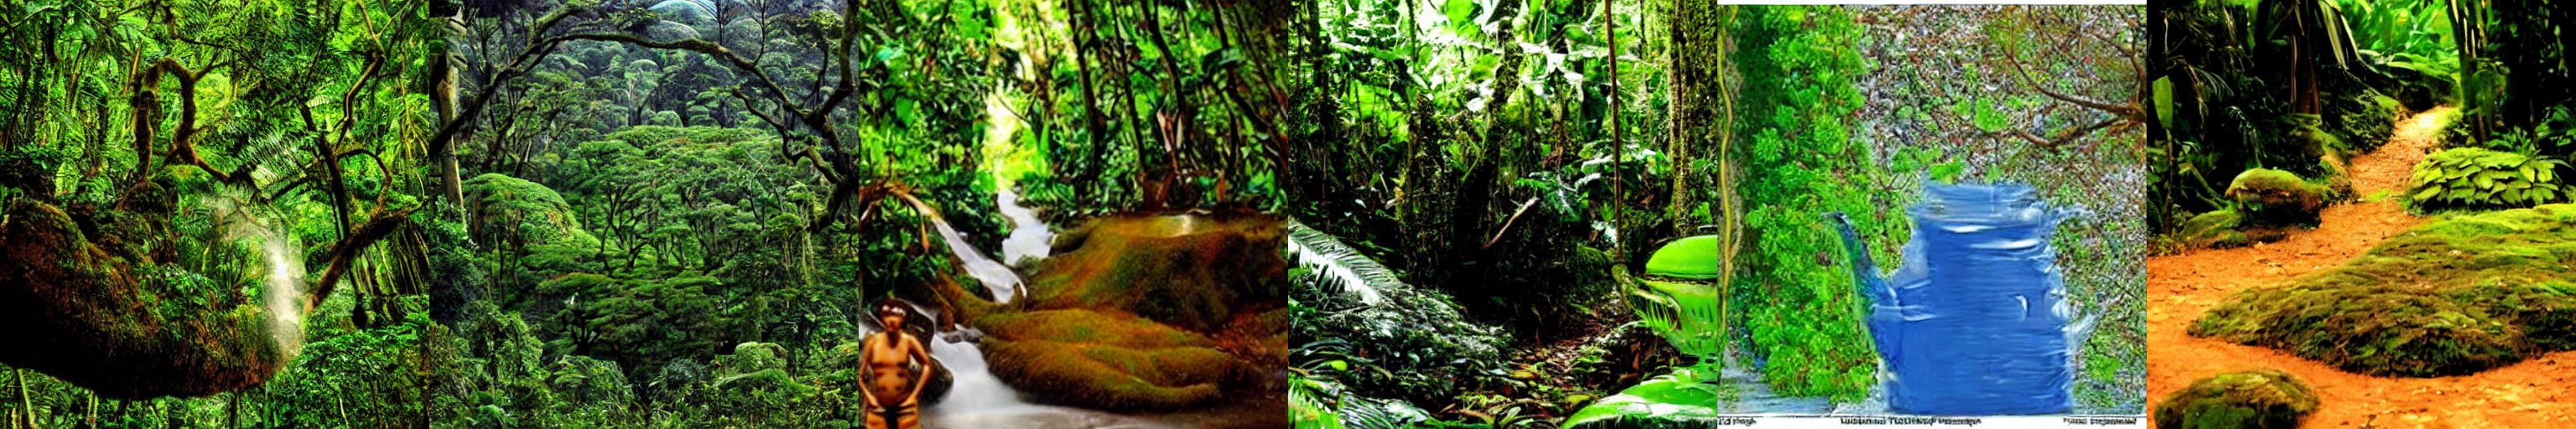

In [11]:
get_image(latents, 1, 6)

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot((ll_obj-ll_bg).cpu().numpy(), c='royalblue')
plt.ylabel('logp_obj - logp_bg')
plt.xlabel('num iterations')
plt.grid()
plt.subplot(122)
plt.plot(kappa.cpu().numpy(), c='royalblue')
plt.ylabel('kappa')
plt.xlabel('num iterations')
plt.grid()

# Averaging

## Stochastic (gotta be compared with stochastic ours)

In [ ]:
# obj_prompt = ["brazilian rainforest"] 
# bg_prompt = ["a shape of a teapot"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion
num_inference_steps = 100  # Number of denoising steps MUST BE > 1000
guidance_scale = 7.5  # Scale for classifier-free guidance
generator = torch.cuda.manual_seed(1)  # Seed generator to create the initial latent noise
# batch_size = len(obj_prompt)
batch_size = 6

obj_embeddings = get_text_embedding(obj_prompt * batch_size)
bg_embeddings = get_text_embedding(bg_prompt * batch_size)
uncond_embeddings = get_text_embedding([""] * batch_size)
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
    device=torch_device,
)
scheduler.set_timesteps(num_inference_steps)
latents = latents * scheduler.init_noise_sigma

In [ ]:
ll_obj = torch.ones((num_inference_steps+1,batch_size), device=torch_device)
ll_bg = torch.ones((num_inference_steps+1,batch_size), device=torch_device)
kappa = 0.5
for i, t in enumerate(scheduler.timesteps):
  dsigma = scheduler.sigmas[i + 1] - scheduler.sigmas[i]
  sigma = scheduler.sigmas[i]
  vel_obj, _ = get_vel(t, sigma, latents, [obj_embeddings])
  vel_bg, _ = get_vel(t, sigma, latents, [bg_embeddings])
  vel_uncond, _ = get_vel(t, sigma, latents, [uncond_embeddings])
  
  vf = vel_uncond + guidance_scale*((vel_bg - vel_uncond) + kappa*(vel_obj-vel_bg))
  dx = 2*dsigma*vf + torch.sqrt(2*torch.abs(dsigma)*sigma)*torch.randn_like(latents)
  latents += dx
  ll_obj[i+1] = ll_obj[i] + (-torch.abs(dsigma)/sigma*(vel_obj)**2 - (dx*(vel_obj/sigma))).sum((1,2,3))
  ll_bg[i+1] = ll_bg[i] + (-torch.abs(dsigma)/sigma*(vel_bg)**2 - (dx*(vel_bg/sigma))).sum((1,2,3))

In [ ]:
get_image(latents, 1, 6)

## Joint prompt

In [ ]:
obj_prompt = ["a brazilian rainforest that looks like a shape of a teapot"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion
num_inference_steps = 100  # Number of denoising steps MUST BE > 1000
guidance_scale = 7.5  # Scale for classifier-free guidance
generator = torch.cuda.manual_seed(1)  # Seed generator to create the initial latent noise
# batch_size = len(obj_prompt)
batch_size = 6

obj_embeddings = get_text_embedding(obj_prompt * batch_size)
uncond_embeddings = get_text_embedding([""] * batch_size)
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
    device=torch_device,
)
scheduler.set_timesteps(num_inference_steps)
latents = latents * scheduler.init_noise_sigma

In [ ]:
ll_obj = torch.ones((num_inference_steps+1,batch_size), device=torch_device)
for i, t in enumerate(scheduler.timesteps):
  dsigma = scheduler.sigmas[i + 1] - scheduler.sigmas[i]
  sigma = scheduler.sigmas[i]
  vel_obj, _ = get_vel(t, sigma, latents, [obj_embeddings])
  vel_uncond, _ = get_vel(t, sigma, latents, [uncond_embeddings])
  
  vf = vel_uncond + guidance_scale*(vel_obj - vel_uncond)
  dx = 2*dsigma*vf + torch.sqrt(2*torch.abs(dsigma)*sigma)*torch.randn_like(latents)
  latents += dx
  ll_obj[i+1] = ll_obj[i] + (-torch.abs(dsigma)/sigma*(vel_obj)**2 - (dx*(vel_obj/sigma))).sum((1,2,3))

In [ ]:
get_image(latents, 1, 6)